# Sesión 1 · Teoría
## Componentes y descomposición de series temporales

**Estadística, Detección de Anomalías e Imputación de Series Temporales**
Posgrado en Ingeniería · Área Energía · IER-UNAM

---

### Objetivos de aprendizaje

Al terminar esta sesión, el estudiante será capaz de:

1. Definir formalmente una serie temporal y enunciar sus componentes.
2. Distinguir entre **tendencia**, **estacionalidad**, **ciclo** y **ruido**.
3. Decidir cuándo conviene un modelo **aditivo** y cuándo uno **multiplicativo**.
4. Explicar la diferencia conceptual entre la descomposición clásica y **STL**.

## Importante

Las celdas de código de esta libreta usan **datos sintéticos** generados con NumPy. La intención es ver cada componente *aislado*, sin la suciedad de un sensor real. Después trabajaremos con datos meteorológicos reales de ESOLMET del IER.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
np.random.seed(42)

## 1. ¿Qué es una serie temporal?

Una **serie temporal** es una secuencia de observaciones $\{y_t\}$ indexada por una variable temporal $t$, donde el orden importa.

$$
y_t,\quad t = 1, 2, \ldots, N
$$

Ejemplos en ingeniería energética:

- Temperatura ambiente cada minuto en una estación meteorológica.
- Demanda eléctrica horaria de un edificio.
- Producción diaria de un sistema fotovoltaico.
- Promedio mensual de irradiancia global.

**Lo que distingue a una serie temporal de un dataset cualquiera** es que las observaciones consecutivas no son independientes: lo que ocurre en $t$ contiene información sobre lo que ocurrirá en $t+1$. Esa **dependencia temporal** es la materia prima de toda esta materia.

### Frecuencia de muestreo

La **frecuencia** $\Delta t$ entre observaciones determina qué fenómenos podemos observar:

| Frecuencia | $\Delta t$ | Fenómenos observables |
|------------|-----------|------------------------|
| Sub-segundo | < 1 s | Transitorios eléctricos, ráfagas turbulentas |
| Minuto | 1 min | Variabilidad de nubes, ciclo diario detallado |
| Hora | 1 h | Ciclo diario, perfiles de carga |
| Día | 1 d | Tendencia estacional anual, ENSO |
| Mes / Año | 1 mes / 1 año | Cambio climático, ciclos solares |

**Principio clave (Nyquist).** Para resolver un fenómeno con período $T$ se necesita $\Delta t < T/2$.

## 2. Los cuatro componentes de una serie temporal

Cualquier serie temporal puede pensarse como la superposición de cuatro elementos:

$$
y_t = \underbrace{T_t}_{\text{tendencia}} + \underbrace{S_t}_{\text{estacionalidad}} + \underbrace{C_t}_{\text{ciclo}} + \underbrace{R_t}_{\text{ruido}}
$$

(esto es la forma **aditiva**; veremos la multiplicativa en la sección 3).

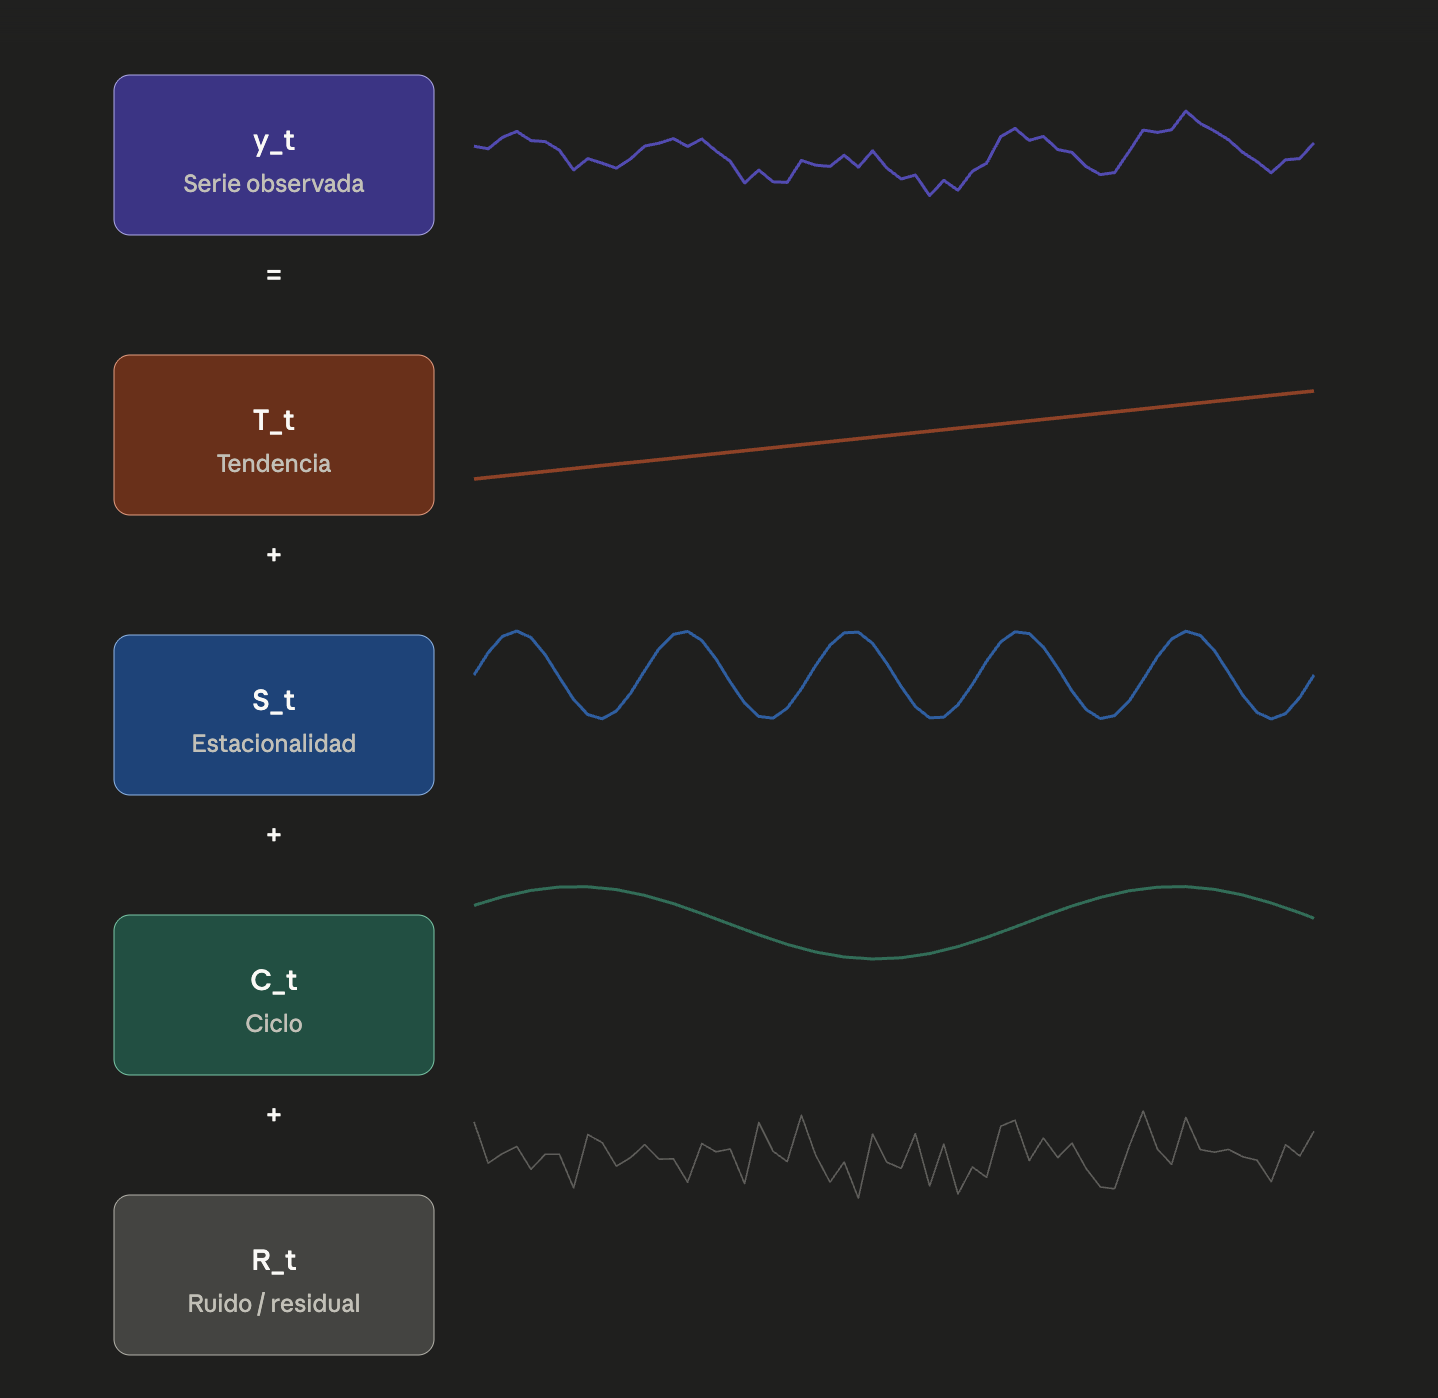

### 2.1 Tendencia $T_t$

Cambio sistemático de largo plazo, **no periódico**. Puede ser monótona (creciente, decreciente) o suavemente curvada.

*Ejemplo:* aumento de la temperatura media anual debido al cambio climático.

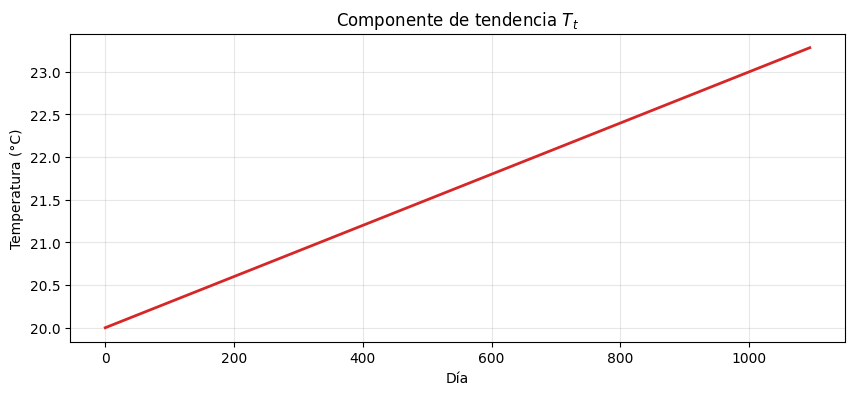

In [2]:
# --- Tendencia sintética ---
n = 365 * 3  # 3 años en días
t = np.arange(n)
trend = 20 + 0.003 * t  # +0.003 °C/día ≈ +1 °C/año

fig, ax = plt.subplots()
ax.plot(t, trend, color="C3", lw=2)
ax.set_xlabel("Día")
ax.set_ylabel("Temperatura (°C)")
ax.set_title("Componente de tendencia $T_t$")
plt.show()

### 2.2 Estacionalidad $S_t$

Patrón **periódico de período fijo y conocido** vinculado al calendario o a un proceso natural recurrente.

| Tipo | Período | Causa física |
|------|---------|---------------|
| Diaria | 24 h | Rotación de la Tierra (sol) |
| Anual | 365 d | Traslación de la Tierra (estaciones) |
| Semanal | 7 d | Patrón humano (laboral / fin de semana) |

La clave: el período es **constante y predecible**.

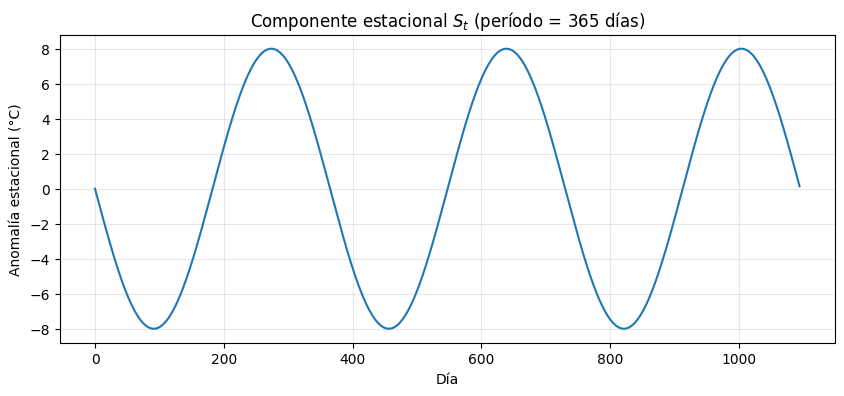

In [6]:
# --- Estacionalidad anual sintética ---
seasonal = 8 * np.sin(2 * np.pi * t / 365 - np.pi / 1)

fig, ax = plt.subplots()
ax.plot(t, seasonal, color="C0", lw=1.5)
ax.set_xlabel("Día")
ax.set_ylabel("Anomalía estacional (°C)")
ax.set_title("Componente estacional $S_t$ (período = 365 días)")
plt.show()

### 2.3 Ciclo $C_t$

Patrón recurrente pero de **período variable o no fijo**. La distinción clave con la estacionalidad es que el ciclo *no* está anclado al calendario.

*Ejemplos:*
- ENSO (El Niño / La Niña): período de 2–7 años.
- Ciclo solar: ~11 años, pero variable.

En la práctica de un curso introductorio, el ciclo suele dejarse fundido con la tendencia (ambos son "lo de baja frecuencia"). En esta materia trabajaremos sobre todo con tendencia + estacionalidad + ruido.

### 2.4 Ruido / residual $R_t$

Lo que queda después de quitar los componentes deterministas. Idealmente:

- Media cero.
- Varianza constante 
- Sin autocorrelación (será un *ruido blanco*).

En la realidad casi nunca lo es del todo, y eso es justo lo que aprovecharemos para **detectar anomalías** (Bloque 4).

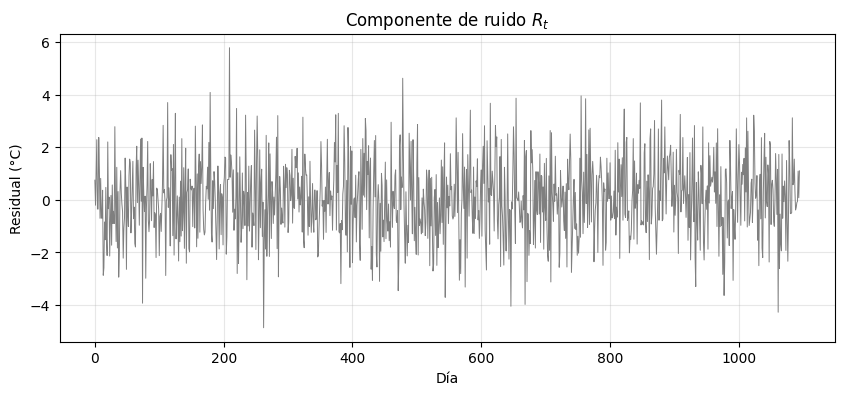

In [7]:
# --- Ruido sintético ---
noise = np.random.normal(0, 1.5, n)

fig, ax = plt.subplots()
ax.plot(t, noise, color="C7", lw=0.7)
ax.set_xlabel("Día")
ax.set_ylabel("Residual (°C)")
ax.set_title("Componente de ruido $R_t$")
plt.show()

In [9]:
noise.mean()

np.float64(0.0494341958983249)

### 2.5 Suma de los componentes

Lo que el sensor mide es la suma:

$$
y_t = T_t + S_t + R_t
$$

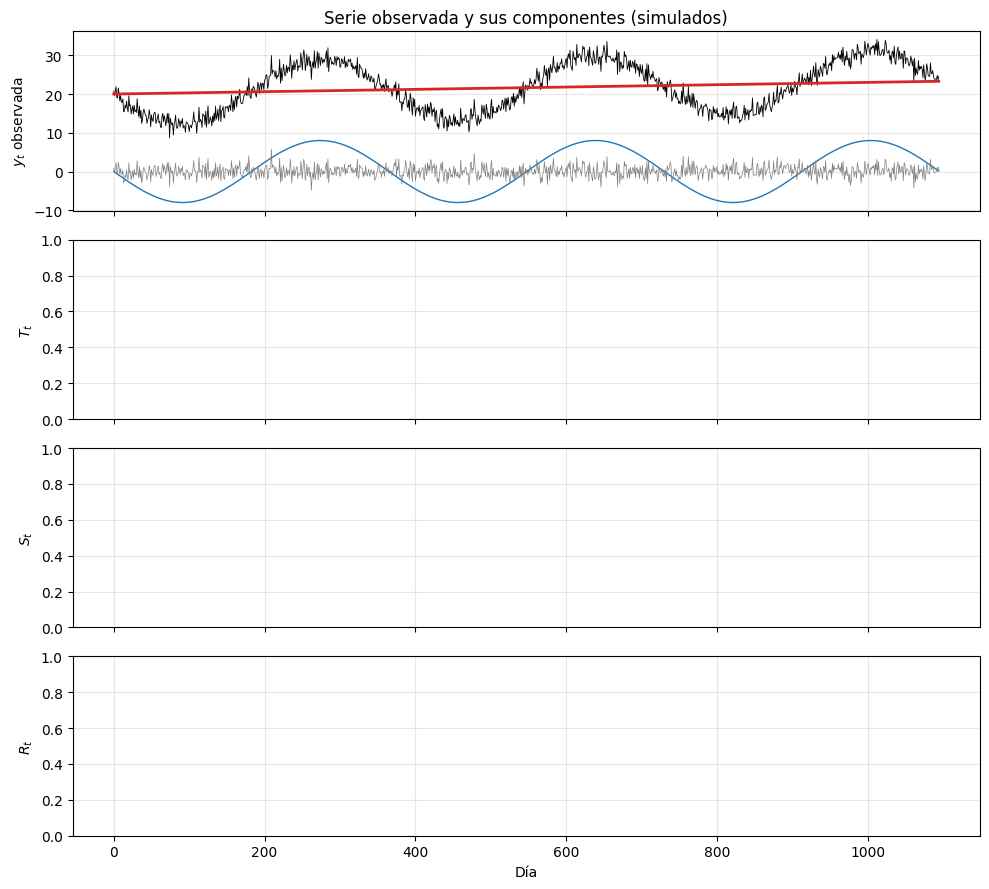

In [12]:
y = trend + seasonal + noise

fig, axes = plt.subplots(4, 1, figsize=(10, 9), sharex=True)

axes[0].plot(t, y, color="black", lw=0.6)
axes[0].set_ylabel("$y_t$ observada")
axes[0].set_title("Serie observada y sus componentes (simulados)")

axes[0].plot(t, trend, color="C3", lw=2)
axes[1].set_ylabel("$T_t$")

axes[0].plot(t, seasonal, color="C0", lw=1)
axes[2].set_ylabel("$S_t$")

axes[0].plot(t, noise, color="C7", lw=0.5)
axes[3].set_ylabel("$R_t$")
axes[3].set_xlabel("Día")

plt.tight_layout()
plt.show()

**Observa:** mirando solo la primera gráfica (la serie completa), los componentes están entremezclados. El objetivo de la **descomposición** es ir en sentido inverso: partir de $y_t$ y recuperar $T_t$, $S_t$, $R_t$.

## 3. Aditivo vs. multiplicativo

Hay dos modelos canónicos:

| Modelo | Ecuación | ¿Cuándo? |
|--------|----------|----------|
| **Aditivo** | $y_t = T_t + S_t + R_t$ | La amplitud estacional es **constante** en el tiempo |
| **Multiplicativo** | $y_t = T_t \cdot S_t \cdot R_t$ | La amplitud estacional **escala con el nivel** de la serie |

### Cómo decidir

La regla empírica más útil: **mira la amplitud del ciclo estacional a lo largo del tiempo**.

- Si las oscilaciones se ven igual de grandes cuando $T_t$ es pequeña que cuando es grande → **aditivo**.
- Si las oscilaciones crecen cuando $T_t$ crece (efecto "abanico") → **multiplicativo**.

Una transformación logarítmica convierte un modelo multiplicativo en uno aditivo:

$$
\log y_t = \log T_t + \log S_t + \log R_t
$$

Por eso, en la práctica, casi todas las herramientas (incluida STL) trabajan en modo aditivo y, si el caso lo amerita, primero aplicamos $\log$.

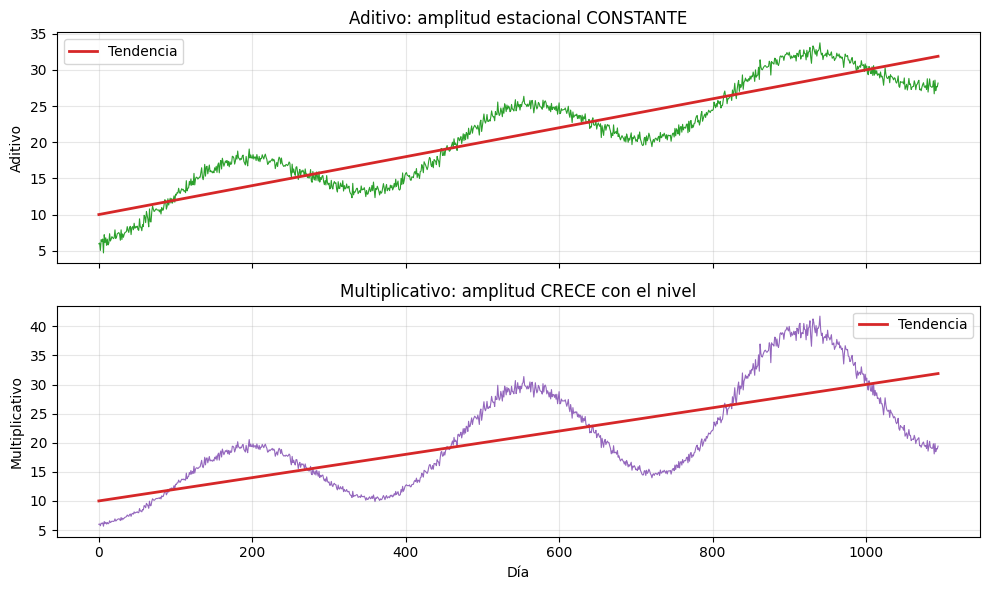

In [13]:
# --- Comparación visual aditivo vs multiplicativo ---
trend2 = 10 + 0.02 * t
season_pattern = np.sin(2 * np.pi * t / 365 - np.pi / 2)
noise2 = np.random.normal(0, 0.5, n)

y_add = trend2 + 4 * season_pattern + noise2          # amplitud constante = 4
y_mul = trend2 * (1 + 0.4 * season_pattern) * (1 + 0.05 * noise2)  # amplitud ~ 40 % del nivel

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(t, y_add, color="C2", lw=0.8)
axes[0].plot(t, trend2, color="C3", lw=2, label="Tendencia")
axes[0].set_ylabel("Aditivo")
axes[0].set_title("Aditivo: amplitud estacional CONSTANTE")
axes[0].legend()

axes[1].plot(t, y_mul, color="C4", lw=0.8)
axes[1].plot(t, trend2, color="C3", lw=2, label="Tendencia")
axes[1].set_ylabel("Multiplicativo")
axes[1].set_xlabel("Día")
axes[1].set_title("Multiplicativo: amplitud CRECE con el nivel")
axes[1].legend()

plt.tight_layout()
plt.show()

### Heurística de bolsillo

> Si al graficar la serie ves un **abanico** que se abre, prueba multiplicativo (o $\log$). Si ves una banda de ancho constante, usa aditivo.

En meteorología, **temperatura** es típicamente aditiva; **radiación solar (GHI)** o **demanda eléctrica de aire acondicionado** suelen ser multiplicativas o requerir transformación.

## 4. Descomposición clásica

El primer algoritmo histórico (años 1920s–1950s) es muy simple y vale la pena entenderlo porque sigue siendo el *default* mental.

**Idea:** estimar la tendencia con una **media móvil**, restarla, y promediar lo que queda *en cada posición del ciclo* para obtener la estacionalidad.

### Algoritmo (modelo aditivo, período $m$)

1. Estimar tendencia: $\hat{T}_t = \mathrm{MA}_m(y_t)$ — media móvil de longitud $m$ centrada.
2. Quitar tendencia: $d_t = y_t - \hat{T}_t$.
3. Estimar estacionalidad: $\hat{S}_t$ = promedio de $d_t$ en cada posición del período (ej. promedio de todos los "1 de enero", "2 de enero", etc.).
4. Residual: $\hat{R}_t = y_t - \hat{T}_t - \hat{S}_t$.

En `statsmodels`, esto es `seasonal_decompose`.

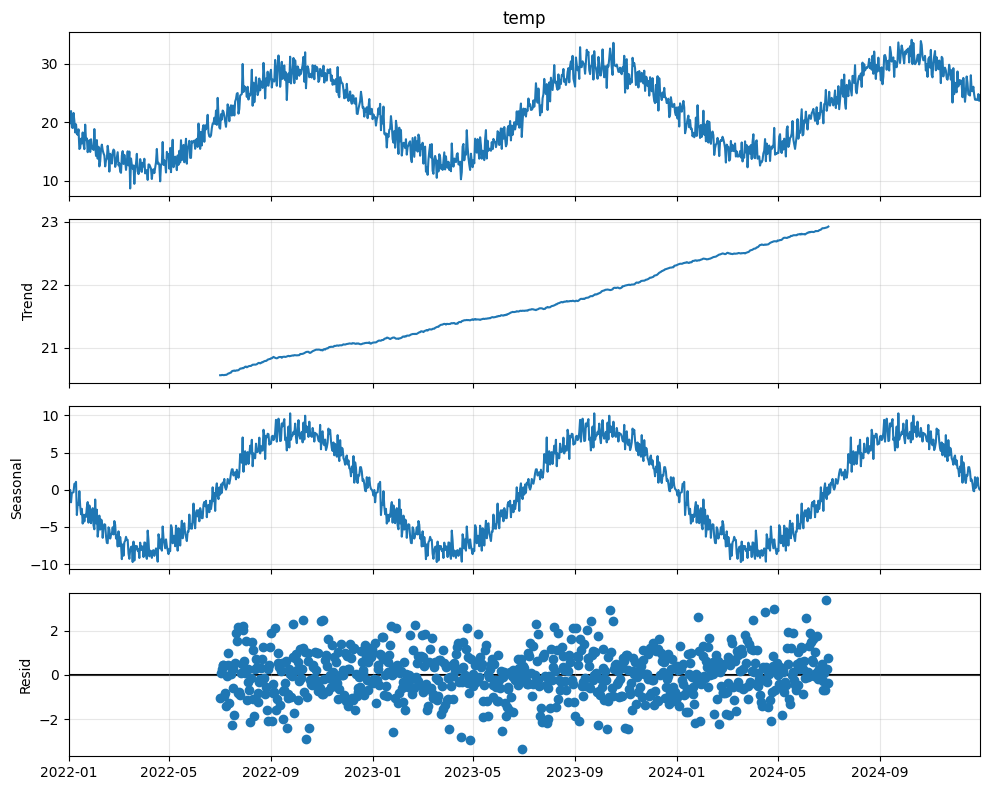

In [16]:
from statsmodels.tsa.seasonal import seasonal_decompose

idx = pd.date_range("2022-01-01", periods=n, freq="D")
serie = pd.Series(y, index=idx, name="temp")

resultado = seasonal_decompose(serie, model="additive", period=365)

fig = resultado.plot()
fig.set_size_inches(10, 8)
plt.tight_layout()
plt.show()

In [19]:
resultado.trend

2022-01-01   NaN
2022-01-02   NaN
2022-01-03   NaN
2022-01-04   NaN
2022-01-05   NaN
              ..
2024-12-26   NaN
2024-12-27   NaN
2024-12-28   NaN
2024-12-29   NaN
2024-12-30   NaN
Freq: D, Name: trend, Length: 1095, dtype: float64

### Limitaciones del método clásico

1. **Pierde datos en los extremos.** La media móvil centrada no se puede calcular en los primeros y últimos $m/2$ puntos, así que esos quedan como NaN.
2. **Estacionalidad rígida.** Asume que el patrón estacional es *idéntico* año tras año. En la realidad climática, los inviernos no son todos iguales.
3. **Sensible a outliers.** Una sola observación anómala contamina la media móvil y, peor, contamina la estacionalidad estimada.
4. **Un solo período.** Si la serie tiene estacionalidad diaria *y* anual a la vez, no las separa bien.

Estas limitaciones motivan **STL**.

## 5. STL: Seasonal-Trend decomposition using LOESS

**STL** (Cleveland et al., 1990) es la herramienta de descomposición que usaremos como referencia en el resto de la materia.

### Idea central

Reemplazar la media móvil por una **regresión local ponderada** (LOESS) que se ajusta en cada punto a sus vecinos. Esto da:

- **Estacionalidad que puede evolucionar** suavemente en el tiempo (no es la misma cada año).
- **Una opción robusta** que pondera menos los outliers (clave para el Bloque 4 de detección de anomalías).
- **Sin pérdida de datos** en los extremos.

### Parámetros principales

| Parámetro | Significado |
|-----------|-------------|
| `period` | Longitud del ciclo estacional en pasos de muestreo (24 si datos horarios con ciclo diario; 365 si datos diarios con ciclo anual) |
| `seasonal` | Suavidad de la componente estacional. Impar, ≥ 7 |
| `trend` | Suavidad de la tendencia. Impar |
| `robust` | Si `True`, pondera a la baja los outliers |

In [21]:
serie

2022-01-01    20.745071
2022-01-02    19.657897
2022-01-03    20.702160
2022-01-04    21.880587
2022-01-05    19.110351
                ...    
2024-12-26    23.850317
2024-12-27    23.767586
2024-12-28    24.780402
2024-12-29    23.632292
2024-12-30    24.518667
Freq: D, Name: temp, Length: 1095, dtype: float64

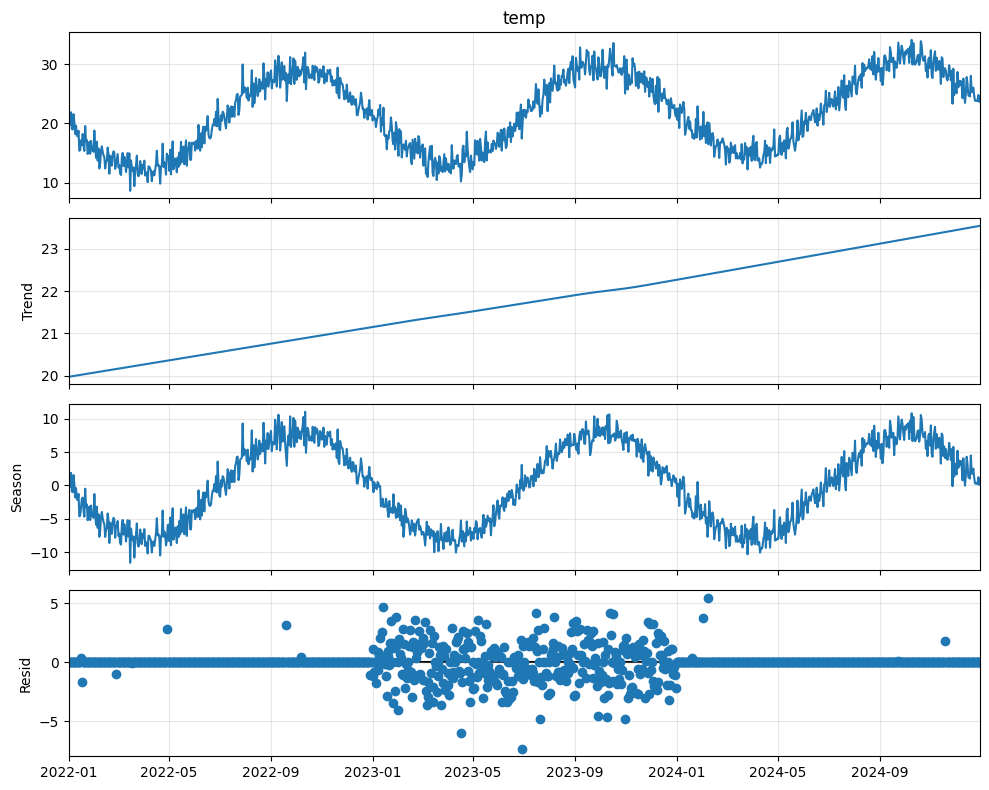

In [20]:
from statsmodels.tsa.seasonal import STL

stl = STL(serie, period=365, robust=True).fit()

fig = stl.plot()
fig.set_size_inches(10, 8)
plt.tight_layout()
plt.show()

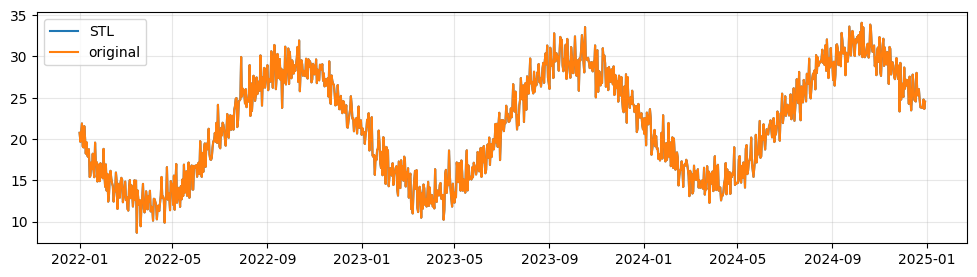

In [41]:
fig, ax = plt.subplots(figsize=(12,3))

ax.plot(
    stl.seasonal 
    + stl.trend 
    + stl.resid
    , label = "STL")
ax.plot(serie,label = "original")

ax.legend()

### Comparación rápida

| Aspecto | Clásica | STL |
|---------|---------|-----|
| Pérdida en bordes | Sí | No |
| Estacionalidad evolutiva | No | Sí |
| Robustez a outliers | Mala | Buena (modo `robust`) |
| Múltiples períodos | No | No (existe MSTL) |

**Para esta materia, STL será la herramienta por defecto.**


### Preguntas para reflexionar antes del laboratorio

1. Si tuvieras temperatura cada minuto durante un año, ¿qué período usarías en STL si quisieras ver el ciclo diario? ¿Y si quisieras ver el ciclo anual?
2. La radiación global horizontal (GHI) vale exactamente 0 W/m² toda la noche. ¿Esto hace que su descomposición sea más complicada o más simple? ¿Por qué?
3. Una estación meteorológica registra una falla de 3 horas en una tarde. ¿Cómo afectará esto a la descomposición clásica? ¿Y a STL en modo `robust`?

### Lectura recomendada (opcional)

- Cleveland, R. B., Cleveland, W. S., McRae, J. E., & Terpenning, I. (1990). *STL: A seasonal-trend decomposition procedure based on Loess*. Journal of Official Statistics, 6(1), 3–73.
- Hyndman, R. J., & Athanasopoulos, G. *Forecasting: Principles and Practice* (3a ed.), capítulo 3. https://otexts.com/fpp3/
